In [14]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

from model import ClassicVAE
from train import ClassicVAE_trainer
from utils import image_to_jax1d, jax_collate_fn, plot_image

In [15]:
import jax
import jax.numpy as jnp
import jax.random as jr
from flax import nnx
import optax

from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

In [16]:
train_dataset = MNIST(root = "./../data", train = True, download = True, transform = image_to_jax1d)
test_dataset = MNIST(root = "./../data", train = False, download = True, transform = image_to_jax1d)

train_data_loader = DataLoader(train_dataset, batch_size = 128, shuffle = True, collate_fn = jax_collate_fn)
test_data_loader = DataLoader(test_dataset, batch_size = 128, shuffle = True, collate_fn = jax_collate_fn)

In [17]:
in_dim = train_dataset[0][0].shape[0]
latent_dim = 64
hidden_dim = 128
rngs = nnx.Rngs(jax.random.PRNGKey(42))
learning_rate = 0.001
epochs = 10

In [18]:
model = ClassicVAE(in_dim = in_dim, latent_dim = latent_dim, hidden_dim = hidden_dim, rngs = rngs)
optimizer = nnx.Optimizer(model, optax.adam(learning_rate))
trainer = ClassicVAE_trainer(model, optimizer, train_data_loader=train_data_loader, test_data_loader=test_data_loader)

In [19]:
trainer(epochs = epochs, rngs = rngs)

100%|██████████| 469/469 [00:21<00:00, 21.34it/s]


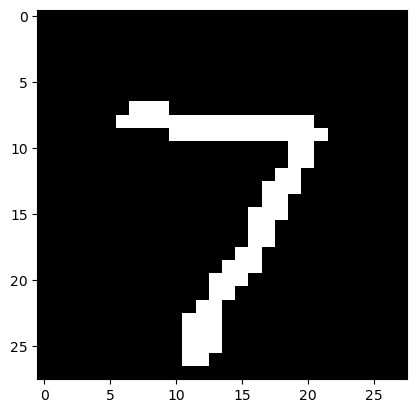

In [23]:
image = test_dataset[0][0]
plot_image(image)

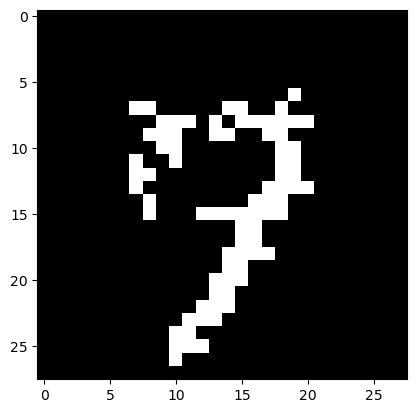

In [24]:
produced_image = model(image, rngs = rngs)
plot_image(produced_image)

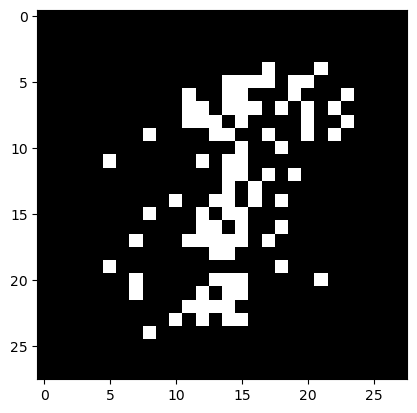

In [66]:
image = model.generate(rngs = rngs)
plot_image(image)